In [1]:
import io
import os
import torch
import zipfile
import requests
import torch.nn
import torchvision
from torch.utils.data import Dataset, DataLoader

import satlaspretrain_models

In [2]:
# Download the EuroSAT_RGB dataset.
# Only go through the downloading and unzipping process if it hasn't been done before.
if not os.path.exists('EuroSAT_RGB/'):
    # Download the EuroSAT_RGB dataset. This is a zip file.
    zip_file_url = 'https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1'

    # Send a GET request to the EuroSAT_RGB Zenodo download URL.
    response = requests.get(zip_file_url)

    # Check if the request was successful.
    if response.status_code == 200:
        # Use BytesIO for the zip file content.
        zip_file = io.BytesIO(response.content)

        # Open the zip file. You should see the EuroSAT_RGB/ folder in this directory.
        with zipfile.ZipFile(zip_file) as zfile:
            # Extract all the contents into the current directory
            zfile.extractall('.')
            print("Zip file extracted successfully.")
    else:
        print(f"Failed to download the zip file. Status code: {response.status_code}")
        

Zip file extracted successfully.


In [3]:
classes = os.listdir('EuroSAT_RGB')

In [4]:
classes

['Forest',
 'River',
 'Highway',
 'AnnualCrop',
 'SeaLake',
 'HerbaceousVegetation',
 'Industrial',
 'Residential',
 'PermanentCrop',
 'Pasture']

In [5]:
cls_to_int = {label: idx for idx, label in enumerate(set(classes))}
int_to_class = {v: k for k, v in cls_to_int.items()}
print("Classes mapped to integers:", cls_to_int)

Classes mapped to integers: {'HerbaceousVegetation': 0, 'PermanentCrop': 1, 'Highway': 2, 'Industrial': 3, 'Forest': 4, 'River': 5, 'Residential': 6, 'Pasture': 7, 'SeaLake': 8, 'AnnualCrop': 9}


In [43]:
class Dataset(Dataset):
    def __init__(self, data_path: str, va:bool = False):

        self.data_points = []
        classes = os.listdir(data_path)
        cls_to_int = {label: idx for idx, label in enumerate(set(classes))}
        for cls in classes:
            cls_int = cls_to_int[cls]
            cls_images = os.listdir(data_path + '/' + cls + '/')
            if va:
                cls_datapoints = [(data_path + '/' + cls + '/' + img, cls_int) for img in cls_images[2400:]]
            else:
                cls_datapoints = [(data_path + '/' + cls + '/' + img, cls_int) for img in cls_images[:2400]]
            self.data_points +=cls_datapoints
        print("Loaded ", len(self.data_points), " datapoints.")


    def __getitem__(self, index):
        img_path, cls_int = self.data_points[index]
        img = torchvision.io.read_image(img_path)
        img = img.float() / 255.0
        target = torch.tensor(cls_int)
        return img, target
    
    def __len__(self):
        return len(self.data_points)



        


            


In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 1
criterion = torch.nn.CrossEntropyLoss()
val_step =1
save_path = 'Weights/'
os.makedirs(save_path, exist_ok=True)

In [45]:
train_dataset = Dataset('EuroSAT_RGB/')
val_dataset = Dataset('EuroSAT_RGB/', va=True)

# Dataloaders.
train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

Loaded  23600  datapoints.
Loaded  3400  datapoints.


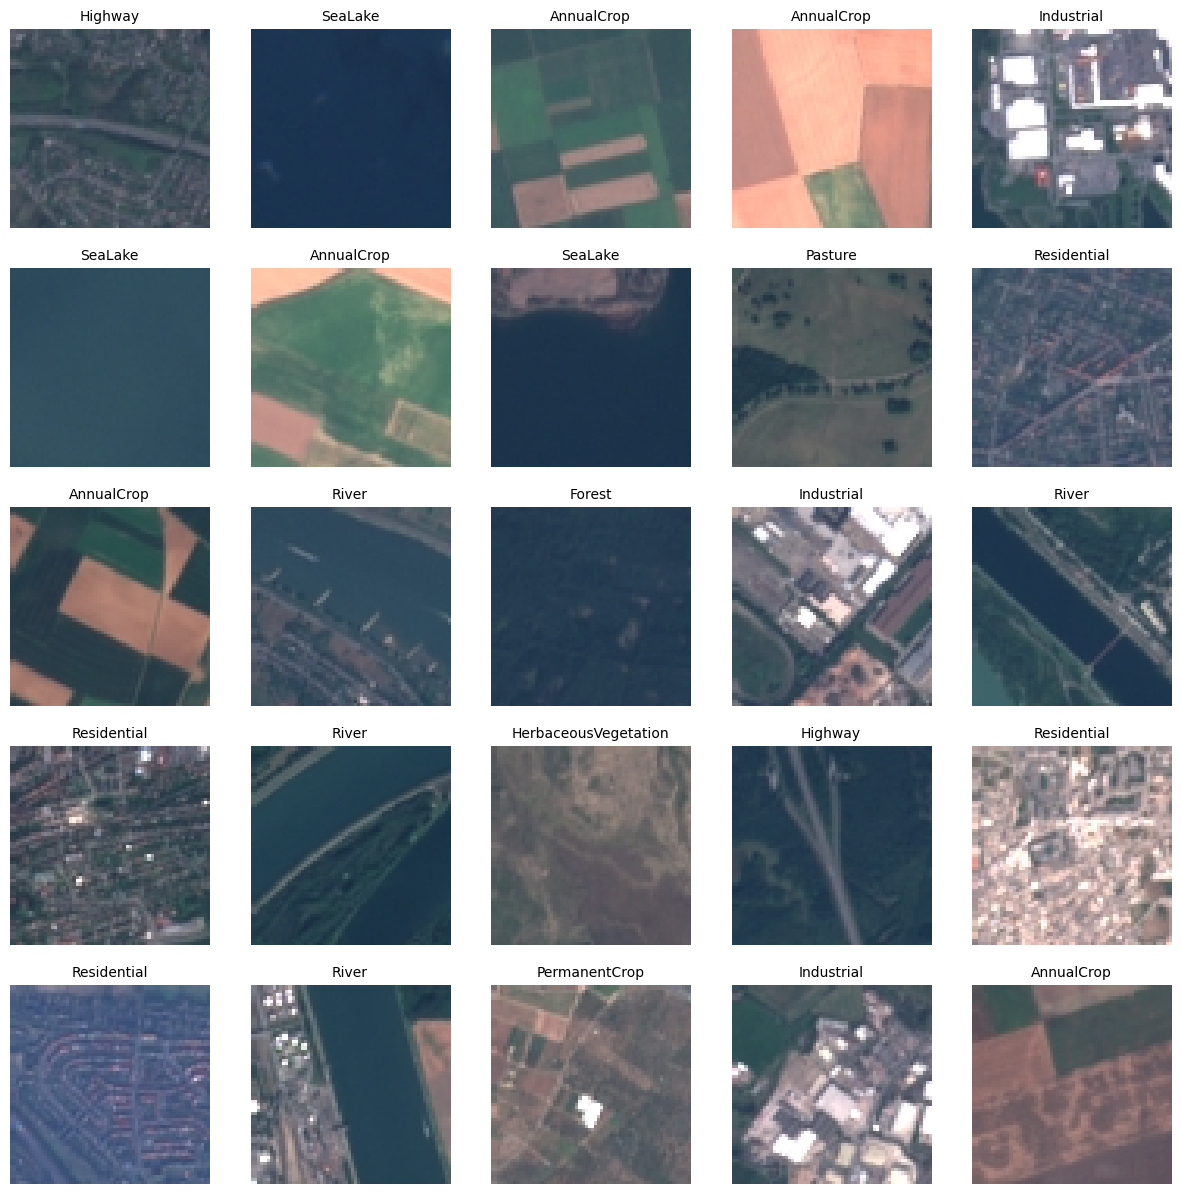

In [46]:
import random
import matplotlib.pyplot as plt

shuffled_indices = torch.randperm(train_dataset.__len__()).tolist()
random_samples = [train_dataset[x] for x in shuffled_indices]

fig, axs = plt.subplots(5, 5, figsize=(15, 15))
for i, ax in enumerate(axs.flat):
    data, target = random_samples[i]
    
    image = data.cpu().numpy()
    target = int(target.cpu().numpy())    
    image = image.transpose(1, 2, 0)

    ax.set_title(int_to_class[target], fontsize=10)
    ax.imshow(image)
    ax.axis('off')

plt.show()

In [47]:
# Initialize a pretrained model, using the SatlasPretrain single-image Swin-v2-Base Sentinel-2 image model weights
# with a classification head with num_categories=10, since EuroSAT has 10 classes.
weights_manager = satlaspretrain_models.Weights()
model = weights_manager.get_pretrained_model("Sentinel2_SwinB_SI_RGB", fpn=True, head=satlaspretrain_models.Head.CLASSIFY, 
                                                num_categories=10, device='cpu')
model = model.to(device)

In [48]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


In [50]:
# Training loop.
for epoch in range(num_epochs):
    print("Starting Epoch...", epoch)

    for data, target in train_dataloader:
        data = data.to(device)
        target = target.to(device)

        output, loss = model(data, target)
        print("Train Loss = ", loss)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        break

    # Validation.
    if epoch % val_step == 0:
        model.eval()

        for val_data, val_target in val_dataloader:
            val_data = val_data.to(device)
            val_target = val_target.to(device)

            val_output, val_loss = model(val_data, val_target)

            val_accuracy = (val_output.argmax(dim=1) == val_target).float().mean().item()
            print("Validation accuracy = ", val_accuracy)

        # Save the model checkpoint at the end of each epoch.
        torch.save(model.state_dict(), save_path + str(epoch) + '_model_weights.pth')

Starting Epoch... 0
Train Loss =  tensor(2.2919, grad_fn=<MeanBackward0>)
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validation accuracy =  0.0
Validati

In [33]:
data = Dataset('EuroSAT_RGB', va=False)
data[5]

[('EuroSAT_RGB/Forest/Forest_864.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2917.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2903.jpg', 4), ('EuroSAT_RGB/Forest/Forest_870.jpg', 4), ('EuroSAT_RGB/Forest/Forest_680.jpg', 4), ('EuroSAT_RGB/Forest/Forest_858.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2095.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2081.jpg', 4), ('EuroSAT_RGB/Forest/Forest_1588.jpg', 4), ('EuroSAT_RGB/Forest/Forest_694.jpg', 4), ('EuroSAT_RGB/Forest/Forest_1205.jpg', 4), ('EuroSAT_RGB/Forest/Forest_119.jpg', 4), ('EuroSAT_RGB/Forest/Forest_1563.jpg', 4), ('EuroSAT_RGB/Forest/Forest_1577.jpg', 4), ('EuroSAT_RGB/Forest/Forest_1211.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2718.jpg', 4), ('EuroSAT_RGB/Forest/Forest_1239.jpg', 4), ('EuroSAT_RGB/Forest/Forest_643.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2730.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2056.jpg', 4), ('EuroSAT_RGB/Forest/Forest_125.jpg', 4), ('EuroSAT_RGB/Forest/Forest_131.jpg', 4), ('EuroSAT_RGB/Forest/Forest_2042.jpg', 4), ('EuroSAT_RGB/Fores

(tensor([[[0.1255, 0.1255, 0.1255,  ..., 0.1059, 0.1020, 0.1255],
          [0.1294, 0.1294, 0.1255,  ..., 0.1059, 0.1020, 0.1294],
          [0.1059, 0.1059, 0.0941,  ..., 0.1059, 0.1020, 0.1137],
          ...,
          [0.1216, 0.1216, 0.1490,  ..., 0.1333, 0.1412, 0.1333],
          [0.1373, 0.1333, 0.1412,  ..., 0.1451, 0.1451, 0.1294],
          [0.1451, 0.1412, 0.1490,  ..., 0.1412, 0.1333, 0.1333]],
 
         [[0.2118, 0.2118, 0.2000,  ..., 0.1804, 0.1765, 0.2000],
          [0.2157, 0.2157, 0.2000,  ..., 0.1804, 0.1765, 0.2039],
          [0.1804, 0.1804, 0.1686,  ..., 0.1804, 0.1765, 0.1882],
          ...,
          [0.2157, 0.2157, 0.2471,  ..., 0.2314, 0.2392, 0.2314],
          [0.2235, 0.2314, 0.2392,  ..., 0.2431, 0.2431, 0.2353],
          [0.2353, 0.2392, 0.2471,  ..., 0.2392, 0.2392, 0.2392]],
 
         [[0.2627, 0.2627, 0.2549,  ..., 0.2392, 0.2353, 0.2588],
          [0.2667, 0.2667, 0.2549,  ..., 0.2392, 0.2353, 0.2627],
          [0.2392, 0.2392, 0.2275,  ...,

In [17]:
classes = os.listdir('EuroSAT_RGB')
cls_to_int = {label: idx for idx, label in enumerate(set(classes))}

8
